# Tokens, Sequences, and Embeddings

Getting started with the foundations of generative language models.

In this set of notes, we’ll begin our discussion of *generative language models*:

<span class="theorem-title">**Definition 1 (Generative Language Model)**</span> A *generative language model* is a machine learning model whose primary functionality is to produce sequences of useful text.

Our aim by the end of these notes is to have a first, functioning generative language model that can produce text in the style of a piece of sample text passed by the user.

In [ ]:
import pandas as pd
from collections import defaultdict
import random
import urllib.request 
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from torch.utils.data import Dataset, DataLoader
import torch
from torch import nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Our sample text for today is the complete text of Shakespeare’s *Hamlet*: <span class="column-margin margin-aside">I accessed the text from the [Folger Shakespeare Library](https://www.folger.edu/explore/shakespeares-works/hamlet/read/).</span>

In [ ]:
url = "https://raw.githubusercontent.com/PhilChodrow/ml-notes-update/refs/heads/main/data/hamlet.txt"
text = "\n".join([line.decode('utf-8').strip() for line in urllib.request.urlopen(url)])

Here are the first few lines:

In [ ]:
print(text[0:193])

Let’s now break down the task of producing some Hamlet-like text into a few key analytical units.

## Tokens

From an abstract point of view, a body of text can be viewed as a *sequence of symbols*.

<span class="theorem-title">**Definition 2 (Token in Language Modeling)**</span> A *token* is an atomic unit of text that serves as the basic unit of learning and prediction for language models. Tokens may be entire words, but may also be units of punctuation, sub-word units like prefixes and roots, or even individual characters.

<span class="column-margin margin-aside">An entertaining fad from a few years ago was seeing models incorrectly answer basic questions about character counts in certain words, reflecting a limitation due to their tokenization schemes.</span>

There are many strategies for tokenization, and you can learn more about them in a dedicated course on natural language processing (NLP). For wotday, we’ll use a simple, popular tokenization strategy called *byte pair encoding* (BPE) <span class="column-margin margin-aside">See [these notes](https://middcs.github.io/data-science-notes/source/31-markov-models.html#byte-pair-tokenization) for more details on BPE.</span> The `Tokenizer`, `BPE`, and `BpeTrainer` classes from the `tokenizers` library, provided via HuggingFace, make it easy to apply BPE tokenization to our chosen body of text:

In [ ]:
# TODO

The *vocabulary* of the tokenizer is the set of all tokens that it has learned to recognize, along with unique integer IDs for each token. Let’s first see how many tokens are in the vocabulary:

In [ ]:
# TODO
print(f"Vocabulary size {len(vocab)}")

We can inspect a few tokens and their corresponding IDs. <span class="column-margin margin-aside">BPE is a partially randomized process, which means that the set of learned tokens may look different each time.</span>

In [ ]:
pd.DataFrame(vocab.items(), columns=['token', 'id']).head(10)

We can use the `encode` method of the tokenizer to convert our desired text (or any other text) into a sequence of token IDs:

In [ ]:
# TODO
print(f"Number of encoded tokens: {len(encoded)}")

Our new data now looks like a sequence of integer ids. We can always convert back to the actual token text using the `decode` method of the tokenizer. Let’s see how this works for the first few tokens:

In [ ]:
for i in range(10): 
    token_id = encoded[i]
    print(f"{token_id:5d} --> {tokenizer.decode([token_id])}")

## Next-Token Prediction

The current dominant paradigm in generative language modeling is called *next-token prediction*. The idea is to train a model to predict the next token in a sequence of tokens, given the previous tokens:

<span class="theorem-title">**Definition 3 (Next-Token Prediction)**</span> In *next-token prediction*, we treat a sequence of tokens $t_1,t_2,\ldots,t_k$ as a set of *features*, and attempt to use them to predict the identity of the next token $t_{k+1}$ in the sequence.

> **Next-Token Prediction is a Classification Problem**
>
> Since the possible values of a given token come from the discrete set of token ids in the vocabulary, we can view next-token prediction as a *classification problem*: given a sequence of tokens, we want to classify the identity of the next token.

#### Context Length and N-Gram Models

There are many different kinds of models which aim to solve the next-token prediction problem. For this chapter, we’ll focus on a simple class of models called *n-gram* models, which use a fixed number of previous tokens as features to predict the next token.

<span class="theorem-title">**Definition 4 (Context Length, N-Gram Models)**</span> The *context length* is the number of previous tokens that we use as features to predict the next token in a next-token prediction problem.

A model that uses a fixed context length of $n$ is often called an *(n+1)-gram* model.

For example, a model with context length 1 is often called a *bigram* model, since it encodes relationships between pairs of tokens (one feature, one target). A model with context length 2 is often called a *trigram* model, since it encodes relationships between triples of tokens (two features, one target).

### Datasets for Next-Token Prediction

We’re now ready to implement a data set for next-token prediction using an $n$-gram model. To do this, we need to organize our sequence of token ids into a data set of training examples, in which each example consists of a sequence of tokens as features and the next token as the target. We can implement this using a custom `Dataset` class in PyTorch. In the `__init__` method we save several instance variables and tokenize the input text, while in the `__len__` and `__getitem__` methods we implement the logic for how to index into the data set to get the features and target for each example.

<span class="column-margin margin-aside">For convenience purposes only, we’ve arranged for the dataset to return both the token ids and the corresponding text for each example. In practice, only the token ids are needed for training – the text is just for debugging and our own entertainment.</span>

In [ ]:
class TextDataSet(Dataset):
    def __init__(self, text, tokenizer = Tokenizer(BPE()), trainer = BpeTrainer(min_frequency=10), context_length = 5): 
        self.context_length = context_length
        self.text = text
        self.tokenizer = tokenizer
        self.tokenizer.train_from_iterator([text], trainer)
        self.tokens = self.tokenizer.encode(text).ids
        self.vocab_length = self.tokenizer.get_vocab_size()

    # TODO

We can construct the data set like this:

In [ ]:
data = TextDataSet(
    text, 
    tokenizer = tokenizer, 
    trainer = trainer, 
    context_length = 5
    )
print(f"Number of training examples: {len(data)}")
print(f"Vocabulary size: {data.vocab_length}")

Having constructed the data set, we can query it with simple indexing.

In [ ]:
for i in range(5): 
    X, y, X_text, y_text= data[i]
    print(f"Example {i}: {X.tolist()} -> {y}")
    print(f"         : '{X_text}' --> '{y_text}'")
    print("")

Let’s add a data loader so that we can train the model with stochastic optimization:

In [ ]:
# TODO

A single batch of data from the loader consists of a tensor of features (token ids) and a tensor of targets (token ids), along with the corresponding text for each example in the batch:

In [ ]:
X_batch, y_batch, X_text_batch, y_text_batch = next(iter(loader))
print(f"Batch of features (token ids): {X_batch.shape}")
print(f"Batch of targets (token ids): {y_batch.shape}")

### From Tokens To Features: One-Hot Encoding

Before we’re ready to train a model for next token prediction, we need to convert our token ids into a format compatible with operations like matrix multiplication. <span class="column-margin margin-aside">We don’t want to simply use the ids themselves as the features, since token `29` is not necessarily “more” than token `10` in a meaningful way.</span>

As our first attempt to convert token ids into feature vectors, we’ll use *one-hot encoding*: we represent each token as a vector of zeros with a single one in the position corresponding to the token’s id. For a sequence of tokens, we concatenate the one-hot vectors for each token to get a single feature vector for the entire sequence.

<figure id="fig-one-hot">
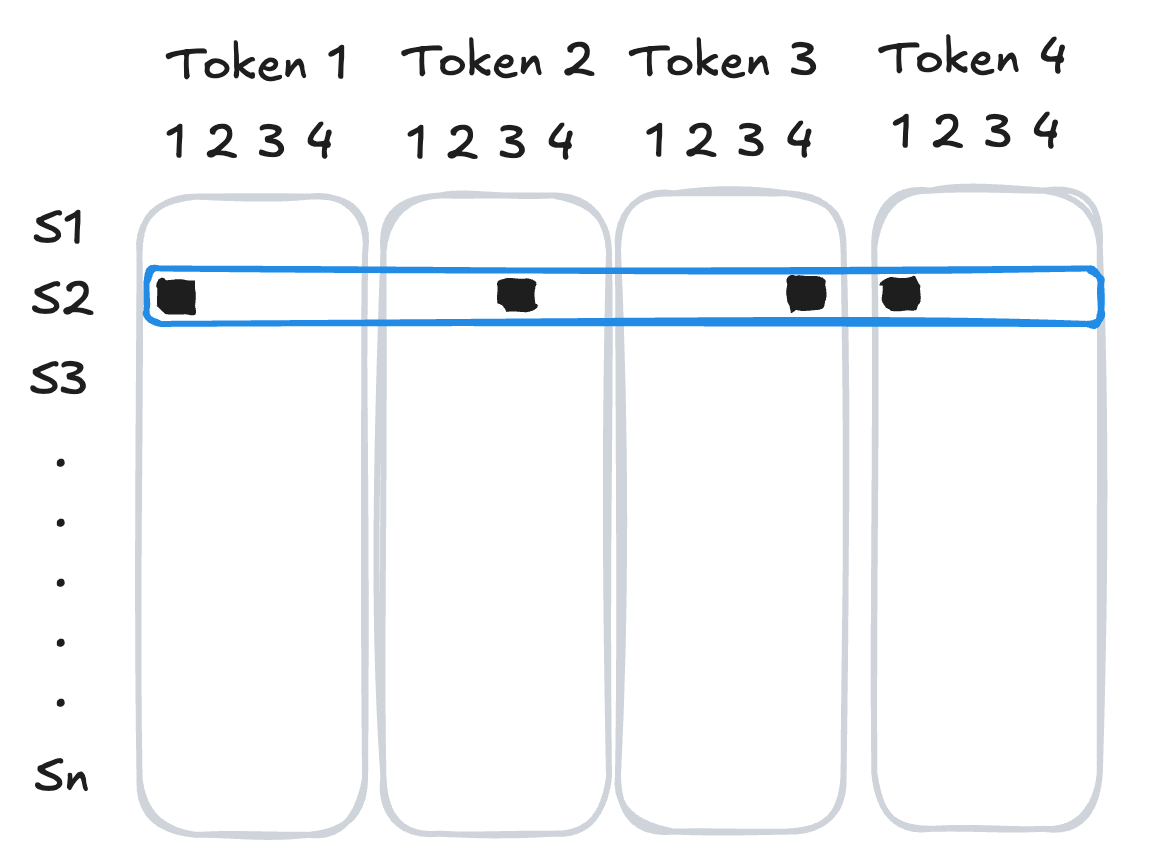
<figcaption>Figure 1: Visual illustration of one-hot encoding: the second sequence in the data set has token ids <code>[1, 3, 4, 1]</code>.</figcaption>
</figure>

The function below implements this logic on a batch of sequences of tokens.

In [ ]:
from torch.nn.functional import one_hot

def one_hot_batch(batch_tokens, m_tokens): 
    return torch.cat([
        one_hot(batch_tokens[:,i], num_classes = m_tokens).float() for i in range(batch_tokens.shape[1])
    ], dim = 1)

Now, if we take a batch of data…

In [ ]:
X_batch, y_batch, X_text_batch, y_text_batch = next(iter(loader))
print(f"Batch of features (token ids): {X_batch.shape}")
print(f"Batch of targets (token ids): {y_batch.shape}")

…we can convert the features into one-hot encoded vectors:

In [ ]:
X_batch_one_hot = one_hot_batch(X_batch, m_tokens = data.vocab_length)
print(f"Batch of features (one-hot): {X_batch_one_hot.shape}")

The second dimension of `X_batch_one_hot.shape` is equal to `context_length * vocab_length`, since we have `context_length` tokens in the features, and each token is represented by a one-hot vector of length `vocab_length`.

## Next-Token Prediction with Neural N-Gram Models

We’re now ready to train a simple neural network to perform $n$-gram next-token prediction with one-hot encoded features. One can do this with any classification model, but these days neural networks are by far the most popular choice for this task. For this example, we’ll use a simple two-layer neural network. For convenience we’ll place the one-hot encoding step inside the `forward` method of the network.

In [ ]:
# TODO

The `input` size of the network must correspond to the one-hot encoded feature vectors, which have length `context_length * vocab_length`. The `output` size of the network must correspond to the number of possible classes for the target token, which is equal to `vocab_length`.

In [ ]:
model = NTP(
    input_size = data.context_length*data.vocab_length, 
    hidden_size = 200, 
    vocab_size = data.vocab_length
    ).to(device)

Now we’re ready to train the model, just like we would on any other classification task.

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.01)
for epoch in range(20):
    total_loss = 0
    for X_batch, y_batch, _, _ in loader:
        opt.zero_grad()
        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {epoch} loss: {total_loss / len(loader)}")

Having trained the model, we can use the `forward` method to get the model’s predicted scores for the next token:

In [ ]:
X, y, X_text, y_text = data[220]

# get the model's predicted scores for the next token
# need to add and then remove a batch dimension to X since the model expects a batch of data as input
preds = model.forward(X.unsqueeze(0)).squeeze(0)

# top 5 preds and their corresponding token ids
top_preds = torch.topk(preds, k=5).indices.tolist()

print(f"Feature text: '{X_text}'")
print(f"Top 5 predicted token IDs: {top_preds}")
print(f"Top 5 predicted token texts: {[data.tokenizer.decode([token_id]) for token_id in top_preds]}")
print(f"Scores: {[f'{x:.2f}' for x in preds[top_preds].tolist()]}")
print(f"Actual token ID: {y}")

Given the set of scores, what should our actual prediction be for the next token? In *deterministic prediction*, we simply choose the token with the highest score as our prediction.

In *stochastic prediction*, we treat the scores as defining a probability distribution over the possible next tokens, and we sample from this distribution to get our prediction. The most common choice of probability distribution is the *Boltzmann* distribution.

<span class="theorem-title">**Definition 5 (Boltzman Distribution, Temperature)**</span> Given a vector $\mathbf{s}\in \mathbb{R}^k$ of scores for each of $k$ possible next tokens, the *Boltzmann distribution* is a probability distribution over the $k$ tokens defined by the scores $\mathbf{s}$ and a parameter $T > 0$ called the *temperature*. It has formula

$$
\begin{aligned}
    p(t) = \frac{e^{\beta s_t }}{\sum_{t'} e^{\beta s_{t'} }}\;, 
\end{aligned}
$$

where $\beta = 1/T$.

Larger values of $T$ lead to more random predictions, while smaller values of $T$ lead to more deterministic predictions. <span class="column-margin margin-aside">Random predictions are sometimes called “creative” among certain enthusiasts.</span> In the limit as $T \to 0$, the Boltzmann distribution converges to a distribution that puts all of its mass on the token with the highest score, which is exactly what deterministic prediction does. In the limit as $T \to \infty$, the Boltzmann distribution converges to the uniform distribution over all tokens, which corresponds to completely random prediction.

In [ ]:
def boltzmann_prediction(preds, temperature = 1.0):
    probabilities = torch.nn.Softmax(dim = None)(preds / temperature)
    return torch.multinomial(probabilities, num_samples=1).item()

Since the $T \to 0$ limit of the Boltzmann distribution corresponds to deterministic prediction, we can implement deterministic prediction using the `boltzmann_prediction` function by setting the temperature to a very small value.

Let’s try out the Boltzmann prediction function with different values of the temperature parameter: <span class="column-margin margin-aside">In this code block, we have to `unsqueeze` the input to add a batch dimension, since the model is expecting a batch of sequences of tokens, but we are only supplying a single sequence.</span>

In [ ]:
X, y, X_text, y_text = data[330]
preds = model.forward(X.unsqueeze(0)).squeeze(0)

print(f"Feature text: '{X_text}'")

for temp in [0.01, 0.5, 2.0]: 
    print(f"\nPredictions with temperature {temp}:")
    print("-----------------------------")
    for _ in range(3):
        y_pred = boltzmann_prediction(preds, temperature = temp)
        print(f"Temperature: {temp}, Predicted token: {y_pred}, {data.tokenizer.decode([y_pred])}")

For very low temperatures, the predictions are essentially deterministic, while for higher temperatures, the predictions become more and more random.

## Recurrent Text Generation

To generate text with our trained model, we start with an initial sequence of tokens, and then repeatedly apply the model to predict the next token, appending each predicted token to the sequence and using the updated sequence as the new input for the next prediction.

<figure id="fig-token-prediction">
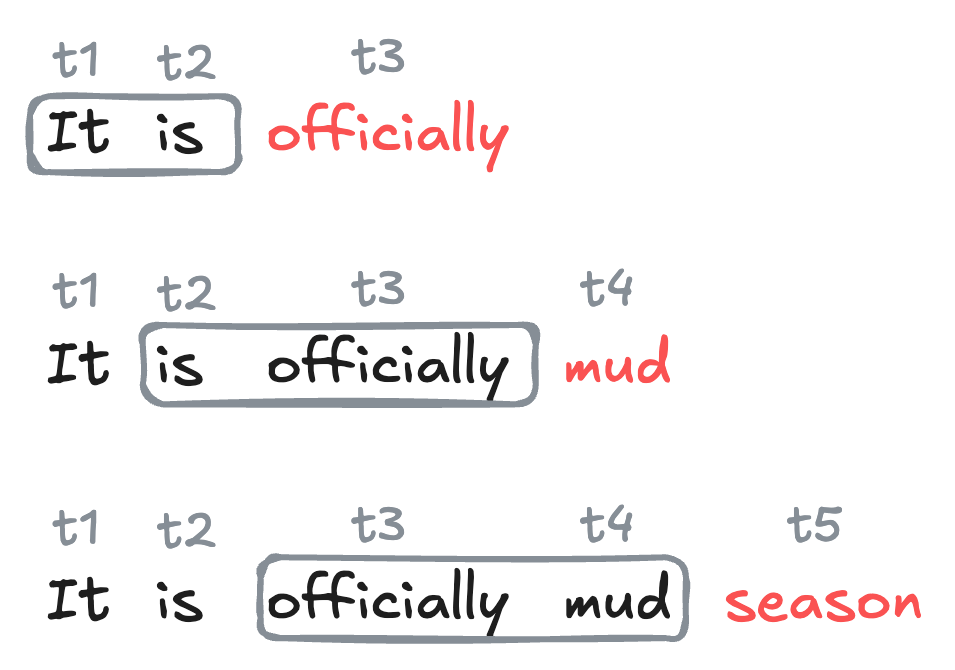
<figcaption>Figure 2: Illustration of recurrent text generation using word-level tokens and a context length of 2. Each newly-generated token is added to the sequence. The oldest token in the context is dropped, so that the context length remains fixed at 2.</figcaption>
</figure>

In [ ]:
# If entire line is all caps, add colon to end and a newline
def format_line(line): 
    if line.isupper():
        return "\n" + line + ":"
    else:
        return line

def format_text(text): 
    text = text.replace("  ", "<SPACE>").replace(" ", "").replace("<SPACE>", " ")
    return "\n".join([format_line(line) for line in text.split("\n")])

def get_cast(text): 
    cast = set()
    for line in text.split("\n"):
        if line.isupper():
            cast.add(line.strip(":"))
    return cast

def display(gen_text): 
    print("Dramatis Personae:")
    for character in get_cast(gen_text):
        print(f"- {character}")
    print("")
    print(gen_text)

The following function implements this logic for generating text with a trained $n$-gram model.

In [ ]:
def generate(model, data, init_tokens, context_length = 5, n_tokens = 200, temperature = 1.0):
    
    generated_tokens = init_tokens
    context = generated_tokens[-context_length:]

    for _ in range(n_tokens):
        model_input = context.unsqueeze(0)
        scores = model.forward(model_input)
        y_pred = boltzmann_prediction(scores, temperature = temperature)
        generated_tokens = torch.cat((generated_tokens, torch.tensor([y_pred], dtype=torch.long)))
        context = generated_tokens[-context_length:]
    decoded = data.tokenizer.decode(
        generated_tokens.tolist(), 
        skip_special_tokens = True
        )
    
    return format_text(decoded)

At very low temperatures, the model always chooses the most probable next token. This tends to lead to deterministic, repetitive text in which the model gets “stuck” in a loop of predicting the same tokens over and over again.

In [ ]:
init_tokens = data[100][0]
context_length = 5

gen_text = generate(model, data, init_tokens, context_length = 5, n_tokens = 300, temperature = 1e-6)
display(gen_text)

At high temperatures, the model predictions are essentially random:

In [ ]:
gen_text = generate(model, data, init_tokens, context_length = 5, n_tokens = 300, temperature = 1000)
display(gen_text)

Somewhere in between, we get more interesting text that displays *some* realistic properties. In this example, the model has learned that CAPITALIZED tokens are likely to appear at the beginning of new lines and after certain punctuation. This is reminiscent of the *syntactic* properties of the text. That said, the lines themselves are still gibberish.

In [ ]:
gen_text = generate(model, data, init_tokens, context_length = 5, n_tokens = 300, temperature = 0.2)
display(gen_text)

## Next-Token Prediction with Embeddings

### Limitations of One-Hot Encoding

There are two important limitations of the one-hot encoding scheme that we used in the previous section.

#### Computational: Feature Vectors Too Large

In the previous batch of models, we associated to each token a one-hot vector of length equal to the number of distinct tokens in the vocabulary. This meant that a given sequence of length $k$ was represented by a vector of length $k \cdot \text{vocab\_length}$; this can quickly become impractically if we wish for either a large vocabulary or a long context length.

#### Semantic: Feature Vectors Not Meaningful

In the one-hot encoding scheme, the feature vector for a given token is just a vector of zeros with a single one in the position corresponding to the token’s id. This means that the feature vectors for different tokens are all orthogonal to each other. From a linear-algebraic perspective, orthogonality means *perfect absence of similarity* – no two tokens are more similar to each other than any other two tokens. This is a missed opportunity: for example, we might expect that the tokens “cat” and “dog” are somewhat more similar to each other than either is to “chair,” but this idea of similarity is not captured by one-hot encoding.

Of course, we *also* don’t want to have to try to write down by hand what better feature vectors for our tokens would look like. So, in the usual spirit of machine learning, we can aim to learn meaningful representations of the tokens *from data*.

<span class="theorem-title">**Definition 6 (Token Embedding)**</span> A *token embedding* is a learned function $f: \{1,2,\ldots,\text{vocab\_length}\} \to \mathbb{R}^d$ that maps each token id to a vector in $\mathbb{R}^d$.

Embeddings can be learned in a variety of ways, but the most common approach is to learn them jointly with the rest of the parameters of a model designed to perform some kind of predictive task, such as text generation or text classification. In this approach, we replace the one-hot encoding step with an embedding layer that maps token ids to vectors, and we learn the parameters of this embedding layer along with the parameters of the rest of the model using gradient descent.

In [ ]:
class NTPEmbedding(torch.nn.Module):
    def __init__(self, vocab_size = 140, embedding_dim = 5, hidden_size = 200):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim * context_length, hidden_size)
        self.fc2 = nn.Linear(hidden_size, vocab_size)

    def forward(self, X):
        # replaces the one-hot encoding step from the last model
        embedded = self.embedding(X).view(X.shape[0], -1) 

        out = torch.nn.ReLU()(self.fc1(embedded))
        out = self.fc2(out)
        return out

Training the model and generating text from it is very similar to the last case:

In [ ]:
context_length = 5
model = NTPEmbedding(vocab_size = data.vocab_length, embedding_dim = 50, hidden_size = 200)

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(20):
    for X_batch, y_batch, _, _ in loader:
        opt.zero_grad()
        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        opt.step()
    print(f"Epoch {epoch} loss: {loss.item()}")

Because the model with embedding does not require one-hot encoding, we need to re-implement the text generation function to work with token ids directly rather than one-hot vectors.

In [ ]:
gen_text = generate(model, data, init_tokens, context_length = 5, n_tokens = 500, temperature = 0.25)

display(gen_text)

In many cases, it can be interesting to inspect the embeddings that the model learns for the tokens. This requires a dimensionality reduction step when the embedding dimension is greater than 2. Here we’ve built a simple embedding visualization, with some of the largest and most complex tokens that appear in the text highlgighted.

Figure 3: 2-dimensional visualization of token embeddings learned by the embedding-based $n$-gram model, with selected tokens highlighted. The embedding is reduced to 2 dimensions using t-SNE, a technique for nonlinear dimensionality reduction.

In [ ]:
from matplotlib import pyplot as plt
embeddings = model.embedding.weight.data

# do TSNE for visualization
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings.numpy())
embeddings = torch.tensor(embeddings_2d, dtype=torch.float)


fig, ax = plt.subplots(figsize=(8, 6))

maximal_tokens = set()
for token in data.tokenizer.get_vocab().keys():
    subtoken = False
    for token2 in data.tokenizer.get_vocab().keys():
        if token in token2 and token != token2:
            subtoken = True
            break
    if not subtoken:
        maximal_tokens.add(token)
    

for i, token in enumerate(data.tokenizer.get_vocab().keys()):
    if token in maximal_tokens:
        if len(token) > 5:
            color = "black"
            size = 20
        else: 
            color = "grey"
            size = 10
        ax.annotate(token, (embeddings[i, 0].item(), embeddings[i, 1].item()),  zorder = 10, color = color, size = size)

lim = 10

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.set_title("Token Embeddings")
ax.set_xlabel("Projected Dimension 1")
l = ax.set_ylabel("Projected Dimension 2")

In some cases the embeddings learned by the model can be interpretable and contain transferable knowledge for downstream tasks. For example, Google’s [Embedding Projector](https://projector.tensorflow.org/) makes it easy to visualize several popular embeddings learned by text models, with words sharing related meanings often appearing close together in the embedding space.